# 1. Project overview



# 2. Imports

In [74]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# 3. Load data and duplicates

The data shows an ID collision error because completely different individuals were mistakenly assigned the exact same `customer_id`. This is clear because a single ID displays impossible changes over time, such as a customer's age dropping significantly between registration dates. 

There are 60 duplicated rows with 30 duplicated clients. The records with duplicated `customer_id` contain different demographic data. Therefore, it can be assumed that these are genuine time series representing a natural lifecycle, where changes in the database indicate, for example, a relocation or a package upgrade. 

In [59]:
data = pd.read_csv("../data/subscription_customers_dirty.csv")

data.head()

,customer_id,age,city,plan,acquisition_channel,join_date,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
0,C000001,32,Poznań,Basic,referral,2022-05-21,7500.94,37,15,1,9.0,1,5,149.74,0
1,C000002,38,Łódź,Standard,paid_search,2024-11-26,5549.57,7,0,0,6.0,1,0,94.50,0
2,C000003,39,Warszawa,Basic,referral,2023-05-25,13992.16,25,9,3,6.0,1,0,127.67,0
3,C000004,39,Warszawa,Standard,organic,2022-09-29,8370.21,33,8,0,7.0,1,15,175.89,0
4,C000005,38,Gdańsk,Premium,referral,2025-06-07,9492.17,1,14,0,7.0,1,0,167.46,1


In [60]:
dup_cols = ['customer_id', 'age', 'city', 'plan', 'acquisition_channel', 'join_date']
duplicates = data[data.duplicated(subset=['customer_id'], 
                                  keep=False)].sort_values(by='customer_id')[dup_cols]

print(duplicates)

     customer_id  age      city      plan acquisition_channel   join_date
60       C000061   48   Wrocław  Standard         paid_search  2022-03-05
7447     C000061   26    Kraków   Premium             organic  2025-03-07
5727     C000494   39  Katowice  Standard             organic  2024-01-06
493      C000494   24    Lublin  Standard         paid_search  2024-10-31
884      C000885   41    Lublin     Basic             partner  2024-07-06
3095     C000885   34   Wrocław   Premium         paid_search  2024-10-21
5061     C001389   46  Katowice     Basic         paid_search  2025-06-06
1388     C001389   54    Poznań   Premium            referral  2022-07-17
1528     C001529   42   Wrocław  Standard             organic  2023-07-20
7651     C001529   19      Łódź  Standard             organic  2025-03-18
1942     C001943   31   Wrocław  Standard         paid_search  2022-09-14
1310     C001943   31    Gdańsk  Standard         paid_search  2024-05-12
8056     C002540   36    Gdańsk    Bas

# 4. Data quality & cleaning 

Instead of removing entire rows with data errors, they were replaced with `NaN` values.

* `age`: Replaced values $< 18$ or $\ge 99$ with `NaN` to handle outliers and out-of-scope entries.
* `monthly_spend_pln`: Replaced negative values with `NaN`. Rows with missing values in this target variable were dropped, followed by an index reset.
* `monthly_income_pln`: Replaced negative values and known sentinel missing code values (`999999`) with `NaN`.

In [61]:
data.drop(columns=['customer_id', 'join_date'], inplace=True)

categorical_cols = ['city', 'plan', 'acquisition_channel']
for col in categorical_cols:
    data[col] = data[col].str.strip().str.lower()

data.loc[
    (data['age'] >= 99) |
    (data['age'] < 18),
    'age'
] = np.nan

data.loc[
    (data['monthly_spend_pln'] < 0),
    'monthly_spend_pln'
] = np.nan

data.loc[
    (data['monthly_income_pln'] < 0) |
    (data['monthly_income_pln'] == 999999),
    'monthly_income_pln'
] = np.nan

data['monthly_spend_pln'].isna().sum()
data = data.dropna(subset=["monthly_spend_pln"]).reset_index(drop=True)

print("Missing values after cleaning:")
display(data.isna().sum().sort_values(ascending=False))

Missing values after cleaning:


monthly_income_pln          157
satisfaction_score          130
city                        109
age                           8
plan                          0
acquisition_channel           0
tenure_months                 0
avg_logins_last_30d           0
support_tickets_last_30d      0
auto_renew                    0
discount_pct                  0
monthly_spend_pln             0
churned                       0
dtype: int64

# 5. Exploratory data analysis

* `data.info()` shows a general overview of the dataset. The dataset contains $9,967$ rows and $13$ columns. It includes both numerical and categorical variables. Some columns contain missing values. The missing values appear in `age`, `city`, `monthly_income_pln`, and `satisfaction_score`. The other columns have complete data.

* `data.describe()` presents average customer is about $35$ years old and has been with the company for around $21$ months. The average monthly income is approximately $8,653 PLN$, while the average monthly spend is about $140$ PLN. Most customers log in around $11$ times during the last 30 days. The average satisfaction score is about $7.8$ out of $10$. Most customers also have autom-renew enabled.
The `monthly_spend_pln` variable has a large range, from $0$ to $2,500 PLN$. This may suggest the presence of some unusually high values, that can be outl.

* Based on the heat map, `tenure_months` and `avg_logins_last_30d` appear to have the strongest relationship with `monthly_spend_pln`.


In [62]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       9989 non-null   float64
 1   city                      9888 non-null   object 
 2   plan                      9997 non-null   object 
 3   acquisition_channel       9997 non-null   object 
 4   monthly_income_pln        9840 non-null   float64
 5   tenure_months             9997 non-null   int64  
 6   avg_logins_last_30d       9997 non-null   int64  
 7   support_tickets_last_30d  9997 non-null   int64  
 8   satisfaction_score        9867 non-null   float64
 9   auto_renew                9997 non-null   int64  
 10  discount_pct              9997 non-null   int64  
 11  monthly_spend_pln         9997 non-null   float64
 12  churned                   9997 non-null   int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 1015.4+ KB


,age,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
count,9989.000000,9840.000000,9997.000000,9997.000000,9997.000000,9867.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,35.217139,8663.042901,20.793138,10.688306,0.666500,7.807135,0.768731,7.192158,139.985437,0.192658
std,9.652617,3985.200991,12.237488,4.431403,1.055299,1.271001,0.421665,7.459601,66.396193,0.394406
min,18.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,5832.465000,10.000000,8.000000,0.000000,7.000000,1.000000,0.000000,109.510000,0.000000
50%,35.000000,7824.505000,21.000000,11.000000,0.000000,8.000000,1.000000,5.000000,138.490000,0.000000
75%,42.000000,10599.945000,31.000000,14.000000,1.000000,9.000000,1.000000,15.000000,166.170000,0.000000
max,71.000000,35000.000000,42.000000,29.000000,12.000000,10.000000,1.000000,20.000000,2500.000000,1.000000


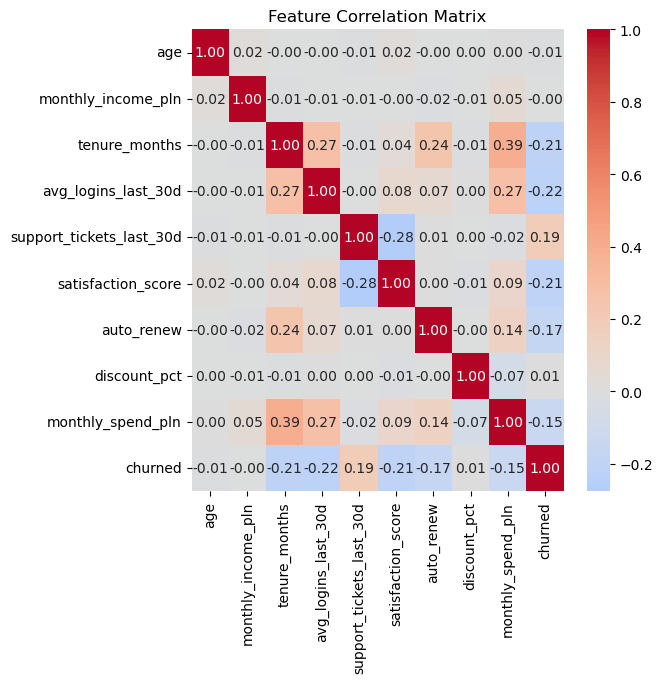

In [63]:
plt.figure(figsize=(6, 6))
sns.heatmap(data.select_dtypes("number").corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f") 
plt.title('Feature Correlation Matrix')
plt.show()

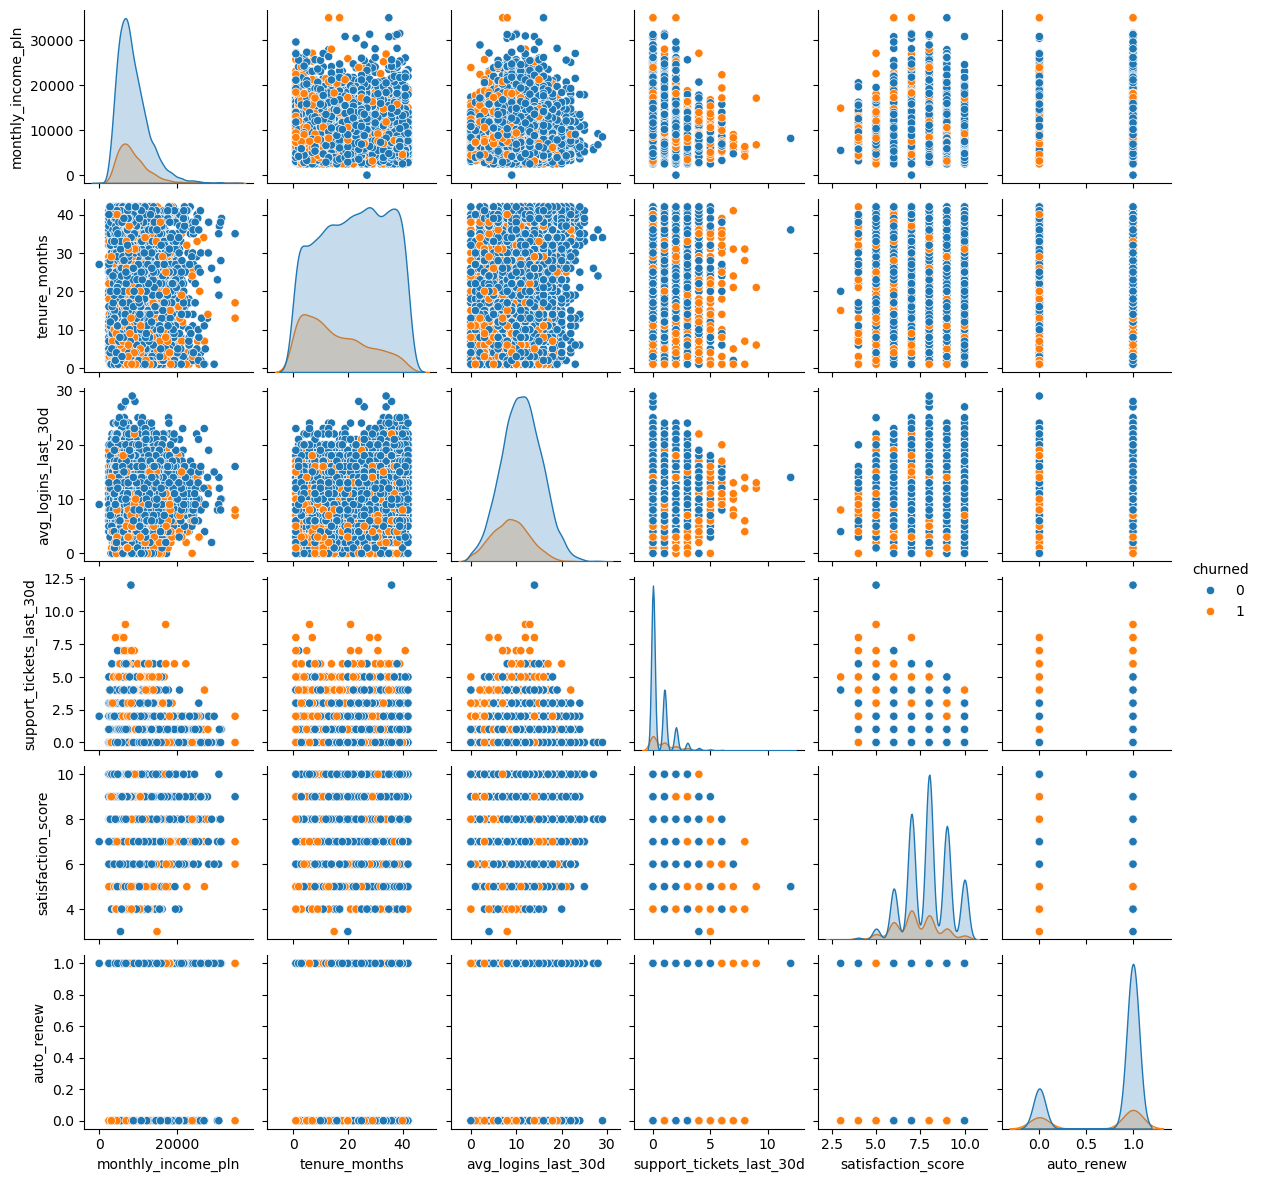

In [64]:
cols = [
    'monthly_income_pln',
    'tenure_months',
    'avg_logins_last_30d',
    'support_tickets_last_30d',
    'satisfaction_score',
    'auto_renew',
    'churned'
]

sns.pairplot(data[cols], hue='churned', height=2)
plt.show()

# 6. Feature engineering and target definition

In this step, the features are separated from the target variable. The target variable is `monthly_spend_pln` so it is removed from input features. Churned was also excluded because it represents an outcome that may occur after or be directly related to the prediction period. Including it could introduce target leakage depending on when the feature is observed

The `high_spend` variable contains `monthly_spend_pln values` ​​with values ​​above 500. There are 5 such records that have the same value of 2500. They could be treated as erroneous data however such values ​​are theoretically possible, and the remaining feature columns do not contain errors in the data.

In [65]:
X = data.drop(columns=[
    "monthly_spend_pln",
    "churned"
])
y = data["churned"]

X["satisfaction_per_tenure"] = (
    X["satisfaction_score"] / (X["tenure_months"] + 1)
)

X["satisfaction_per_tenure"]

high_spend = data["monthly_spend_pln"] >= 500
data[high_spend]

,age,city,plan,acquisition_channel,monthly_income_pln,tenure_months,avg_logins_last_30d,support_tickets_last_30d,satisfaction_score,auto_renew,discount_pct,monthly_spend_pln,churned
2388,47.0,wrocław,standard,social,10716.70,10,6,1,9.0,0,10,2500.0,0
2933,36.0,lublin,basic,organic,2840.60,12,16,0,6.0,0,20,2500.0,1
3272,42.0,łódź,basic,paid_search,14278.43,37,11,2,7.0,1,10,2500.0,0
3371,19.0,lublin,standard,paid_search,10223.06,28,6,0,8.0,1,0,2500.0,0
9698,33.0,kraków,standard,organic,7617.57,11,9,1,NaN,0,20,2500.0,0


# 7. Train/test split

Standard split is used ($80/20$). The model learns from the training data, while the test data is used later to check how well the final model works on unseen data. Set `random_state=42` to make the split reproducible.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 8. Preprocessing pipeline

For numerical features, missing values are replaced with the median and the values are standardized.
For categorical features, missing values are replaced with the most frequent value. Then, categorical variables are converted into numerical values using one-hot encoding.

All preprocessing steps are placed inside a scikit-learn pipeline. This makes sure that the preprocessing is fitted only on the training data and to avoid data leackage.

In [71]:
reg_numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler())])
reg_categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
numeric_selector = make_column_selector(dtype_include="number")
categorical_selector = make_column_selector(dtype_include="object")

preprocessor = ColumnTransformer([('num', reg_numeric_transformer, numeric_selector),
                                 ('cat', reg_categorical_transformer, categorical_selector)])

In [72]:
pipelines = { 
    "Logistic Regression": Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression())]), 
    "Decision Tree": Pipeline([('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier())]), 
    "Random Forest": Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier())]), 
    "KN": Pipeline([('preprocessor', preprocessor), ('classifier', KNeighborsClassifier())]), 
    "SVC": Pipeline([('preprocessor', preprocessor), ('classifier', SVC())]), 
    "XGB": Pipeline([('preprocessor', preprocessor), ('classifier', XGBClassifier())]),
    "Gradient Boosting": Pipeline([('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier())]),
    "LGBM": Pipeline([('preprocessor', preprocessor), ('classifier', LGBMClassifier())])
}

# 9. Cross validation

The models were compared using 5-fold cross-validation with Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The XGBoost model achieved the highest F1-score (0.314) and the best balance between Precision and Recall. The Decision Tree had the highest Recall (0.331), but its ROC-AUC was relatively low (0.573).

Logistic Regression achieved the highest Accuracy (0.824), Precision (0.631), and ROC-AUC (0.766). However, its Recall was only 0.196, which means that many customers who actually churn are not detected.

For this reason, XGBoost, Logistic Regression, and LightGBM should be considered for further analysis. The next step is to optimize the classification threshold, especially for Logistic Regression, to improve Recall and potentially increase the F1-score.


In [75]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in pipelines.items():
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Accuracy std": scores["test_accuracy"].std(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

comparison_cv = (
    pd.DataFrame(cv_results)
    .sort_values("CV F1", ascending=False)
    .reset_index(drop=True)
)

comparison_cv

,Model,CV Accuracy,CV Accuracy std,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Decision Tree,0.722896,0.004398,0.294628,0.314784,0.303992,0.567479
1,XGB,0.794923,0.006078,0.437379,0.229315,0.300357,0.703828
2,Gradient Boosting,0.816180,0.008172,0.563146,0.198909,0.293543,0.754802
3,LGBM,0.809928,0.007325,0.514858,0.205128,0.292972,0.735635
4,Logistic Regression,0.820932,0.008877,0.613315,0.191462,0.291210,0.762570
5,KN,0.793172,0.005951,0.416896,0.189782,0.260755,0.653161
6,Random Forest,0.811428,0.009347,0.538287,0.148487,0.232297,0.733287
7,SVC,0.816180,0.008813,0.613819,0.120423,0.201178,0.683287


[LightGBM] [Info] Number of positive: 1538, number of negative: 6459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 629
[LightGBM] [Info] Number of data points in the train set: 7997, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.192322 -> initscore=-1.434992
[LightGBM] [Info] Start training from score -1.434992


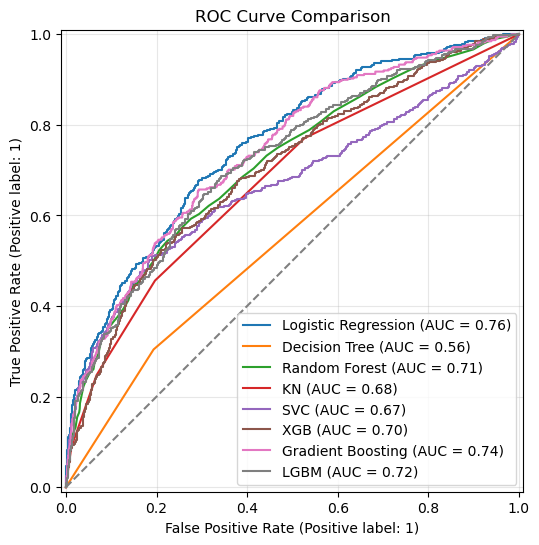

In [76]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in pipelines.items():

    model.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Random classifier'
)

ax.set_title('ROC Curve Comparison')
ax.grid(alpha=0.3)

plt.show()

# 10. Hyperparameter Optimization

In [77]:
optimization_pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "XGB": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]),

    "LGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(
            random_state=42,
            verbosity=-1
        ))
    ])
}

In [ ]:
param_distributions = {

    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["liblinear", "lbfgs"],
        "classifier__class_weight": [None, "balanced"]
    },

    "XGB": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__max_depth": [3, 4, 5, 6, 8],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0]
    },

    "LGBM": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__max_depth": [-1, 3, 5, 7, 10],
        "classifier__num_leaves": [15, 31, 50, 75],
        "classifier__min_child_samples": [10, 20, 30, 50],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [ ]:
best_models = {}
optimization_results = []

for name in optimization_pipelines:

    print(f"Optimizing {name}...")

    search = RandomizedSearchCV(
        estimator=optimization_pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=30,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_

    optimization_results.append({
        "Model": name,
        "Best CV F1": search.best_score_,
        "Best Parameters": search.best_params_
    })

In [ ]:
optimization_results_df = pd.DataFrame(
    optimization_results
)

optimization_results_df[
    ["Model", "Best CV F1"]
]

# 11 Threshold Optimization

In [ ]:
threshold_results = {}

for name, model in best_models.items():

    # Probability of class 1 = churned
    y_proba = model.predict_proba(X_test)[:, 1]

    results = []

    for threshold in np.arange(0.05, 0.96, 0.01):

        y_pred_threshold = (
            y_proba >= threshold
        ).astype(int)

        results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_test,
                y_pred_threshold,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                y_pred_threshold,
                zero_division=0
            ),
            "F1": f1_score(
                y_test,
                y_pred_threshold,
                zero_division=0
            )
        })

    threshold_results[name] = pd.DataFrame(results)

In [ ]:
optimal_thresholds = []

for name, results in threshold_results.items():

    best_row = results.loc[
        results["F1"].idxmax()
    ]

    optimal_thresholds.append({
        "Model": name,
        "Optimal Threshold": best_row["Threshold"],
        "Precision": best_row["Precision"],
        "Recall": best_row["Recall"],
        "F1": best_row["F1"]
    })

optimal_thresholds_df = (
    pd.DataFrame(optimal_thresholds)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

optimal_thresholds_df

In [ ]:
final_thresholds = {}

final_predictions = {}

for name, model in best_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    threshold = optimal_thresholds_df.loc[
        optimal_thresholds_df["Model"] == name,
        "Optimal Threshold"
    ].iloc[0]

    y_pred = (
        y_proba >= threshold
    ).astype(int)

    final_thresholds[name] = threshold
    final_predictions[name] = y_pred

In [ ]:
threshold_comparison = []

for name, model in best_models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    # Default threshold = 0.5
    y_pred_default = (
        y_proba >= 0.5
    ).astype(int)

    # Optimized threshold
    threshold = final_thresholds[name]

    y_pred_optimized = (
        y_proba >= threshold
    ).astype(int)

    threshold_comparison.append({
        "Model": name,

        "Default Precision": precision_score(
            y_test,
            y_pred_default,
            zero_division=0
        ),

        "Default Recall": recall_score(
            y_test,
            y_pred_default,
            zero_division=0
        ),

        "Default F1": f1_score(
            y_test,
            y_pred_default,
            zero_division=0
        ),

        "Optimal Threshold": threshold,

        "Optimized Precision": precision_score(
            y_test,
            y_pred_optimized,
            zero_division=0
        ),

        "Optimized Recall": recall_score(
            y_test,
            y_pred_optimized,
            zero_division=0
        ),

        "Optimized F1": f1_score(
            y_test,
            y_pred_optimized,
            zero_division=0
        )
    })

threshold_comparison_df = pd.DataFrame(
    threshold_comparison
)

threshold_comparison_df

# 12. Final Model Evaluation

In [ ]:
for result in optimization_results:
    print(f"\n{result['Model']}")
    print("Best F1:", result["Best CV F1"])
    print("Best parameters:")

    for param, value in result["Best Parameters"].items():
        print(f"  {param}: {value}")

In [ ]:
original_f1 = (
    comparison_cv[
        comparison_cv["Model"].isin(
            ["Logistic Regression", "XGB", "LGBM"]
        )
    ][["Model", "CV F1"]]
    .rename(columns={"CV F1": "Original CV F1"})
)

optimized_f1 = (
    optimization_results_df[
        ["Model", "Best CV F1"]
    ]
    .rename(columns={"Best CV F1": "Optimized CV F1"})
)

comparison_optimization = (
    original_f1
    .merge(optimized_f1, on="Model")
)

comparison_optimization["F1 Improvement"] = (
    comparison_optimization["Optimized CV F1"]
    - comparison_optimization["Original CV F1"]
)

comparison_optimization = (
    comparison_optimization
    .sort_values("Optimized CV F1", ascending=False)
    .reset_index(drop=True)
)

comparison_optimization

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    y_proba = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "Test F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "Test ROC-AUC": roc_auc_score(
            y_test, y_proba
        )
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values("Test F1", ascending=False)
    .reset_index(drop=True)
)

test_results_df

In [ ]:
best_model_name = test_results_df.iloc[0]["Model"]

final_model = best_models[best_model_name]

print("Best model:", best_model_name)

In [ ]:
print(final_model)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_final = final_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    cmap=plt.cm.Blues,
    display_labels=["not churned", "churned"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in best_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

ax.set_title("ROC Curve — Optimized Models")
ax.grid(alpha=0.3)

plt.show()

# 13. Feature Importance / Model Interpretation